<h2> Task : Heart Disease Prediction

**Objective:**  

Build a model to predict whether a person is at risk of heart disease based on their health data.


**Pandas:** A Python library used for data manipulation and analysis using DataFrames and Series.

**NumPy:** A Python library for fast numerical computing and working with arrays and matrices.

**Matplotlib:** A Python library used to create static, animated, and interactive visualizations.

**Seaborn:** A statistical data visualization library built on Matplotlib that creates attractive plots with less code.

**Scikit-learn (sklearn):** A machine learning library that provides tools for data preprocessing, model training, and evaluation.

In [1]:
# Import necessary libraries and packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)



**Dataset:**


Heart Disease UCI Dataset, A dataset with different type features help to predict heart disease.

| Column        | Meaning                                                           |
| ------------- | ----------------------------------------------------------------- |
| **age**       | Age of the patient (years)                                        |
| **sex**       | Gender (1 = Male, 0 = Female)                                     |
| **cp**        | Chest pain type (different categories of chest pain)              |
| **trestbps**  | Resting blood pressure (mm Hg)                                    |
| **chol**      | Serum cholesterol level (mg/dL)                                   |
| **fbs**       | Fasting blood sugar > 120 mg/dL (1 = Yes, 0 = No)                 |
| **restecg**   | Resting ECG (electrocardiogram) results                           |
| **thalach**   | Maximum heart rate achieved during exercise                       |
| **exang**     | Exercise-induced angina (1 = Yes, 0 = No)                         |
| **oldpeak**   | ST depression induced by exercise relative to rest                |
| **slope**     | Slope of the peak exercise ST segment                             |
| **ca**        | Number of major vessels (0–3) colored by fluoroscopy              |
| **thal**      | Thalassemia test result (normal, fixed defect, reversible defect) |
| **condition** | Target variable (0 = No heart disease, 1 = Heart disease)         |


In [2]:
# Load CSV file of data using pandas

raw_data = pd.read_csv('heart_cleveland_upload.csv')
print('File loaded successsfuly')

File loaded successsfuly


In [3]:
# Create copy of original data to save raw data from accidental changes
df = raw_data.copy()
print('Copy of Raw Data Created')

Copy of Raw Data Created


In [4]:
# Print few rows using head command()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='str')

In [6]:
# Just check, how each value is distributed, 
df['condition'].value_counts(normalize=True)*100   # It shows there is no imbalance in data which is good.



condition
0    53.872054
1    46.127946
Name: proportion, dtype: float64

In [7]:
# Print Shape of data

df.shape

(297, 14)

In [8]:
# Check missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [9]:
# Brief idea of missing values and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [10]:
#Taking the idea, how values distributed in columns and identifimg extreme values if exist.
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


**Insights:**
I found there are chances of extreme values in some of features like trestbps, chol, thalach and in age by comparing mean,std,min and max values.

In [11]:
# Checking duplicates
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, condition]
Index: []


In [12]:

# For checking outliers
# use z_score method

from scipy.stats import zscore

# check outliers in columns
z_score = df[['chol','thalach','trestbps']].apply(zscore)

# Rows containing outliers(threshold = 3)
outliers = df[(z_score.abs()>3).any(axis=1)]

print('These are the rows where outliers exist.')
print('-'* 100)

print(outliers)

These are the rows where outliers exist.
----------------------------------------------------------------------------------------------------
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
45    54    1   1       192   283    0        2      195      0      0.0   
79    67    0   2       115   564    0        2      160      0      1.6   
83    65    0   2       140   417    1        2      157      0      0.8   
164   67    1   3       120   237    0        0       71      0      1.0   
180   63    0   3       150   407    0        2      154      0      4.0   
234   56    0   3       200   288    1        2      133      1      4.0   
238   56    0   3       134   409    0        2      150      1      1.9   

     slope  ca  thal  condition  
45       0   1     2          1  
79       1   0     2          0  
83       0   1     0          0  
164      1   0     0          1  
180      1   3     2          1  
234      2   2     2          1  
238      1 

In [13]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<h3>Exploratory Data Analysis (EDA) 

<h5> To understand trends and identifiy outliers

<h4>Boxplot()

Shows the distribution of a feature using quartiles and highlights outliers.


**Purpose:** Detect outliers and compare data spread across groups.

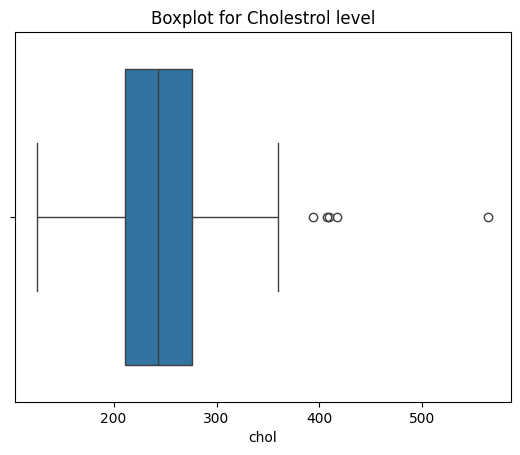

In [14]:
# Boxplot 
#plt.figure(figsize=(8,6))
sns.boxplot(df,x='chol')
plt.title('Boxplot for Cholestrol level')
plt.show()

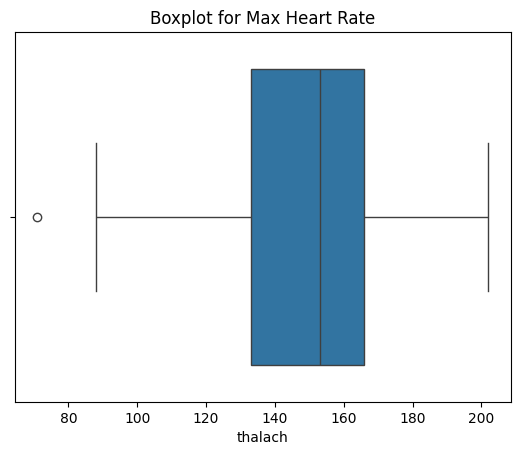

In [15]:
# Boxplot
sns.boxplot(df,x='thalach')
plt.title('Boxplot for Max Heart Rate')
plt.show()

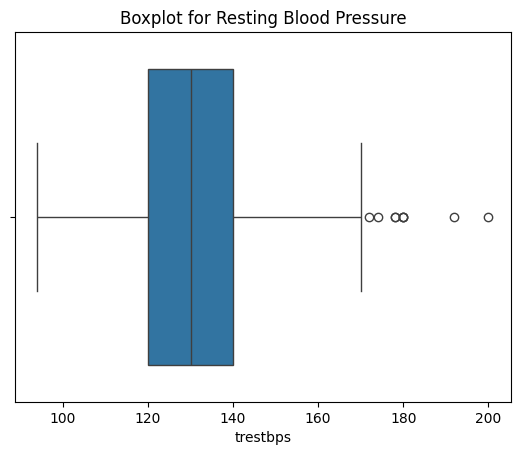

In [16]:
# Box plot
sns.boxplot(df,x='trestbps')
plt.title('Boxplot for Resting Blood Pressure')
plt.show()

**Insight:**
Box plot shows me there are some oultliers in trestbps,chol,thalach.

**Outliers Handling:**

Here i m not going to remove that outliers bcz by doing this, i will lose some of important data that is helpful in prediction. So i will cap them using IQR method

In [17]:
# Handling outliers by caping them
# IQR method is used  here


columns = ['chol','thalach','trestbps']
for col in columns: 
    # calculate q1 and q2

    q1 = df[col].quantile(0.25)     # Find 25th percentile
    q3 = df[col].quantile(0.75)     # Find 75th percentile

    # calculate iqr
    iqr = q3 - q1

    # define lower and upper bound
    lower_bound = q1-1.5*iqr
    upper_bound = q3+1.5*iqr

    # Now cap values
    #np.clip replace upperbound outlier with upper bound and lowerbound outlier with lower bound.
    df[col] = np.clip(df[col],lower_bound,upper_bound)

print('Outliers Caped Successfully') 

Outliers Caped Successfully


In [18]:
# Verifying wheather oultliers removed using zscore method

z = df[['chol','thalach','trestbps']].apply(zscore)

extreme_values = df[(z.abs()>3).any(axis=1)]
print(extreme_values)

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, condition]
Index: []


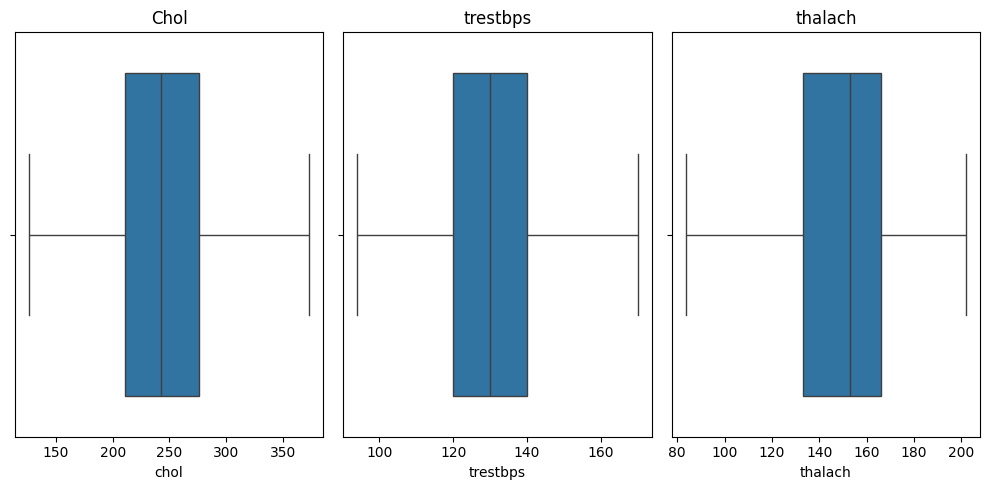

In [19]:
# Again verified outliers through boxplot

# Set figure size with width=10,heigt=5 inch
plt.figure(figsize=(10,5))

# set subplot in 1x3 grid with indexes 1, 2, 3

plt.subplot(1,3,1)
sns.boxplot(df,x='chol')
plt.title('Chol')

plt.subplot(1,3,2)
sns.boxplot(df,x='trestbps')
plt.title('trestbps')

plt.subplot(1,3,3)
sns.boxplot(df,x='thalach')
plt.title('thalach')

plt.tight_layout()
plt.show()

<h3>Heatmap()

The heatmap helped identify the strength and direction of relationships between features and the target variable (heart disease).

It also revealed highly correlated features, which can help in feature selection and detecting multicollinearity before model training.

Uses colors to represent values in a matrix, often a correlation matrix.


Purpose: Quickly visualize correlations and data intensity.

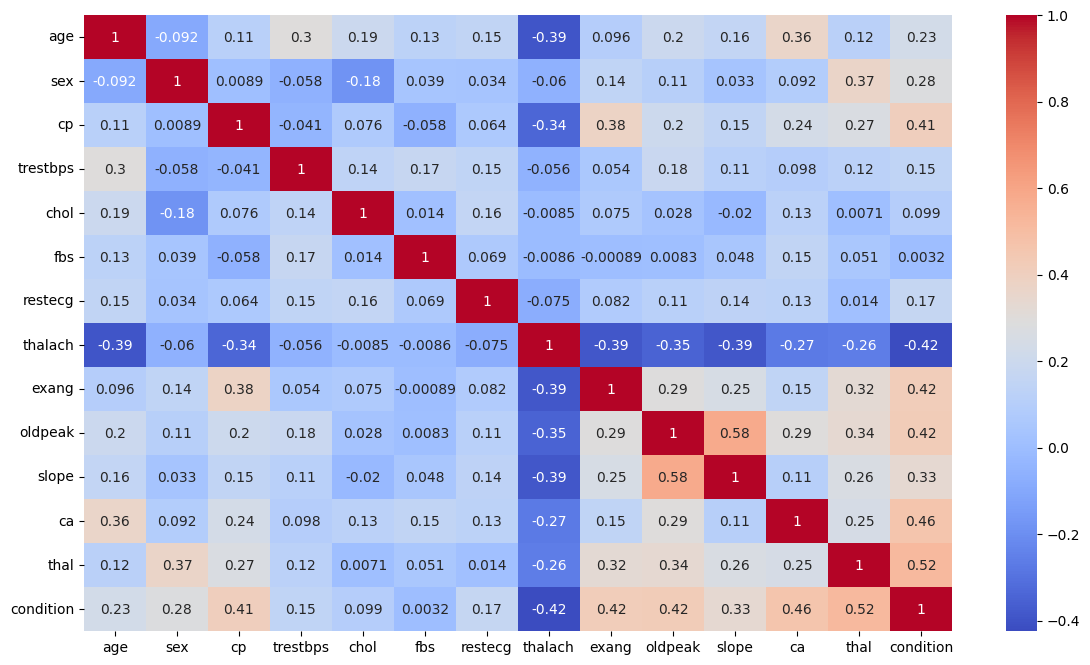

In [20]:
plt.figure(figsize=(14,8))
# annot =True mean shows numbers in boxes, coolwarm is specific color
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

**Insights:**
The heatmap revealed both positive and negative correlations among features. I see variables such as cp (chest pain), thalach (maximum heart rate), slope, ca, and thal showed stronger relationships with the target variable (condition), indicating their importance in heart disease prediction.

There are other features that showes weak to moderate relation with target, but each feature contribute unique information to model

<h5>Scatterplot()

Displays the relationship between two numerical floating variables as points.

**Purpose:** Identify trends, patterns, and correlations.

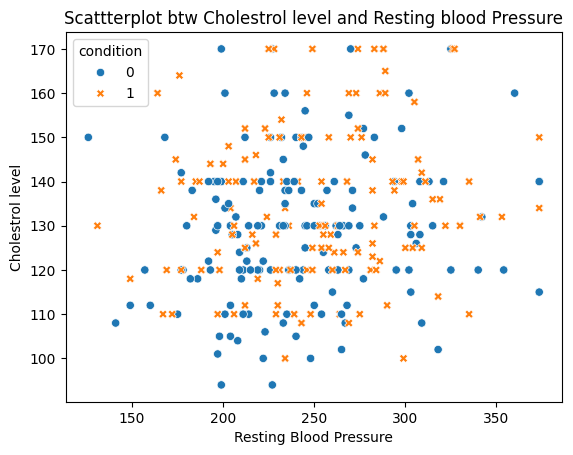

In [21]:
# Relationship of cholestrol level and blood pressure

sns.scatterplot(df,x='chol',y='trestbps',
                hue='condition',
                style='condition')
plt.title('Scattterplot btw Cholestrol level and Resting blood Pressure')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Cholestrol level')
plt.show()

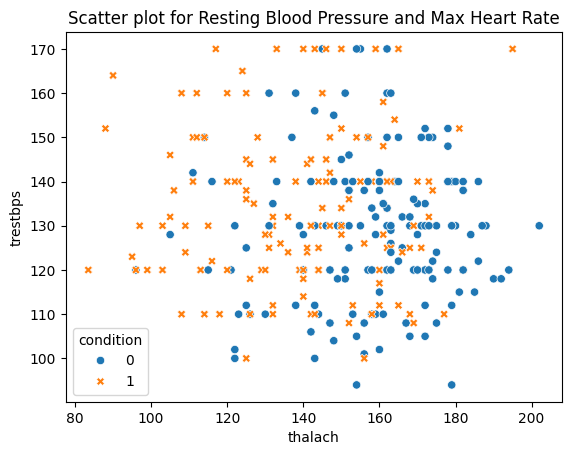

In [22]:
# Relationship btw maximum heart rate and resting blood pressure
sns.scatterplot(df,x='thalach',y='trestbps',
                hue='condition',
                style='condition')
plt.title('Scatter plot for Resting Blood Pressure and Max Heart Rate')
plt.show()

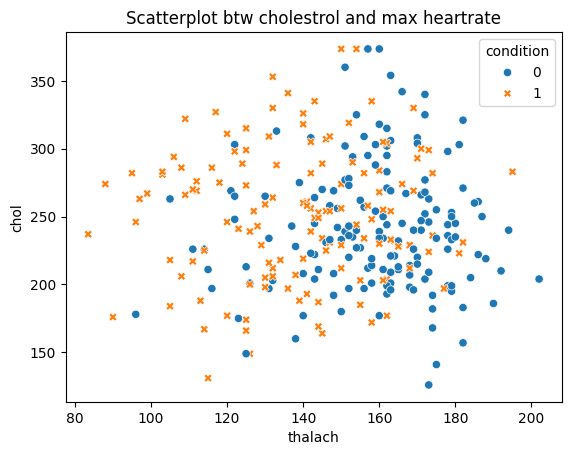

In [ ]:
#    Scatterplot
sns.scatterplot(df,x='thalach',y='chol',hue='condition',style='condition')
plt.title('Scatterplot btw cholestrol and max heartrate')
plt.show()

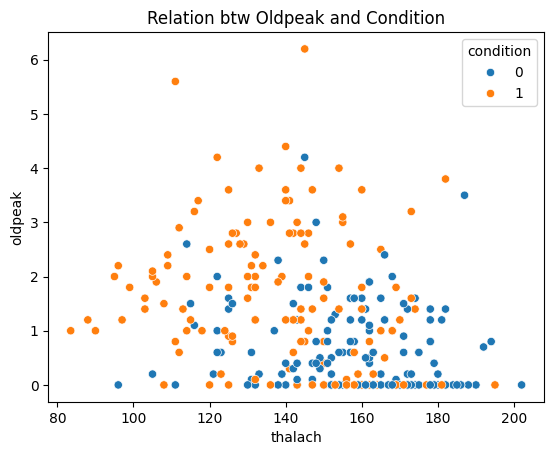

In [23]:
sns.scatterplot(df,x='thalach',y='oldpeak',hue='condition')
plt.title('Relation btw Oldpeak and Condition')
plt.show()

**Insights:**
The scatter plots showed that patients with and without heart disease overlap across cholesterol (chol), resting blood pressure (trestbps), and maximum heart rate (thalach) values, indicating that no single feature can perfectly separate the classes.

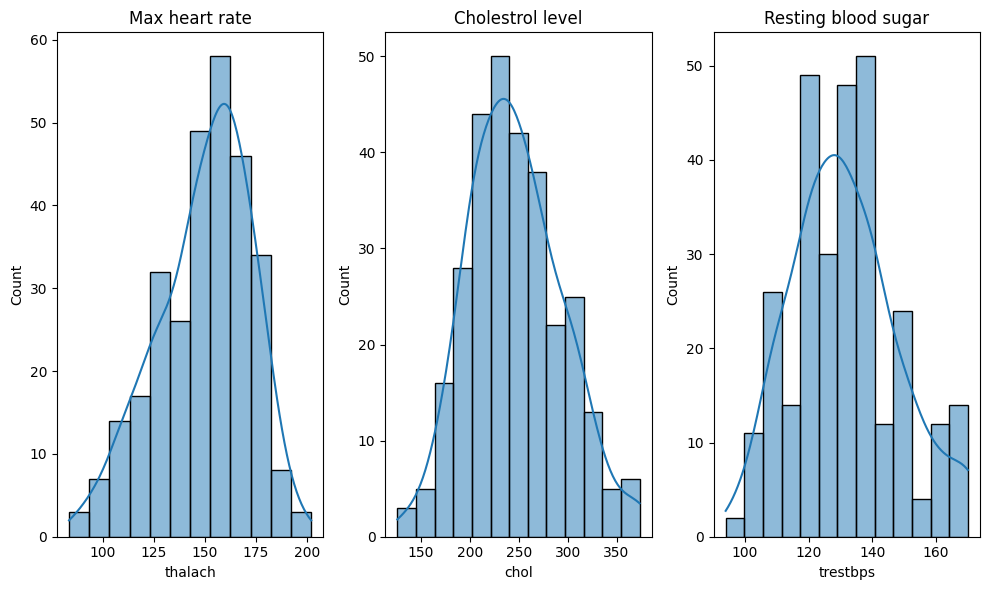

In [ ]:
#  Histplot

plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
sns.histplot(df,x='thalach',kde=True)
plt.title('Max heart rate')

plt.subplot(1,3,2)
sns.histplot(df,x='chol',kde=True)
plt.title('Cholestrol level')

plt.subplot(1,3,3)
sns.histplot(df,x='trestbps',kde=True)
plt.title('Resting blood sugar')

plt.tight_layout()
plt.show()


<h4>Standard Scaling:

In [35]:
# perform scaling to keep data on one scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['chol','thalach','trestbps','age','oldpeak']] = scaler.fit_transform(df[['chol','thalach','trestbps','age','oldpeak']])

In [36]:
print('Columns are Standarized successfully')
print('-'*100)
df[['chol','thalach','trestbps','age','oldpeak']].head()

Columns are Standarized successfully
----------------------------------------------------------------------------------------------------


,chol,thalach,trestbps,age,oldpeak
0,-0.256741,-0.818700,1.708484,1.600302,-0.820813
1,-0.152042,0.059667,0.516098,1.600302,0.639470
2,-0.424258,-1.565312,1.112291,1.268242,1.326662
3,0.748366,1.069789,0.396860,1.157555,0.295874
4,-0.738354,-0.247762,-1.272481,1.046868,0.639470


<h3>Target variable Splitting

We will split whole data into input feature and target variable

In [37]:
# Input features have everything except 'condition'
x = df.drop('condition',axis=1)   # axis = 1 mean dropping column 

# y is target variable that is to be predict
y = df['condition']

In [38]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.600302,1,0,1.708484,-0.256741,1,2,-0.818700,0,-0.820813,1,1,0
1,1.600302,0,0,0.516098,-0.152042,0,0,0.059667,0,0.639470,0,2,0
2,1.268242,0,0,1.112291,-0.424258,0,0,-1.565312,0,1.326662,2,0,0
3,1.157555,1,0,0.396860,0.748366,1,2,1.069789,0,0.295874,1,1,0
4,1.046868,1,0,-1.272481,-0.738354,0,2,-0.247762,1,0.639470,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,-1.609620,1,3,1.231530,-0.487077,0,0,1.377217,0,-0.906712,0,0,2
293,-1.720306,1,3,-0.795526,-0.570836,0,0,-0.423435,0,0.124076,1,0,2
294,-2.163054,1,3,-0.676288,-1.010570,0,0,-0.862618,1,0.467672,1,0,2
295,-2.163054,0,3,0.396860,-1.324666,0,0,1.421136,0,0.295874,0,0,0


In [39]:
y.shape

(297,)

<h4>Split Input features and target variable for traing and testing

In [40]:
# Import train_test_split from sklearn library
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=100) # randomly picked values


<h3> Model Training

Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(max_iter=1000)

lg.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

<h3> Model Prediction

In [56]:
# Model prediction
y_pred = lg.predict(x_test)


<h3> Check Accuracy Score

In [57]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print('\n Logistic regresion accuracy')

print("Accuracy score: {:.2f}%".format(accuracy*100))



 Logistic regresion accuracy
Accuracy score: 88.33%


<h4> DecisionTreeClassifier Training and Prediction

In [44]:
from sklearn.tree import DecisionTreeClassifier

decision_c = DecisionTreeClassifier(max_depth=5)
decision_c.fit(x_train,y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [45]:
#  Prediction
y_decision_pred = decision_c.predict(x_test)

<h3> Decision Tree Accuracy 

In [48]:
print ('Decision Tree Evalution')
print('-'*100)

d_accuracy = accuracy_score(y_test,y_decision_pred)

print("\nAccuracy:{:.2f}%".format(d_accuracy*100))

print('\nClassification report')
print(classification_report(y_test,y_decision_pred))

print('\nConfusion matrix')
print(confusion_matrix(y_test,y_decision_pred))

Decision Tree Evalution
----------------------------------------------------------------------------------------------------

Accuracy:68.33%

Classification report
              precision    recall  f1-score   support

           0       0.66      0.72      0.69        29
           1       0.71      0.65      0.68        31

    accuracy                           0.68        60
   macro avg       0.69      0.68      0.68        60
weighted avg       0.69      0.68      0.68        60


Confusion matrix
[[21  8]
 [11 20]]


In [49]:
# Check Overfitting

print('Train score: ', decision_c.score(x_train,y_train)*100)

print('Test score : ', decision_c.score(x_test,y_test)*100)

# There are difference btw train and test score so there are chances of overfitting.



Train score:  91.9831223628692
Test score :  68.33333333333333


In [50]:
from sklearn.neighbors import KNeighborsClassifier
kn_c = KNeighborsClassifier()

kn_c.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [51]:
y_pred_kn = kn_c.predict(x_test)


In [53]:
print('  KNN Evaution:')
print('-'*100)

accuracy = accuracy_score(y_test,y_pred_kn)
print('Accuracy: {:.2f}%'.format(accuracy*100))

print('\n Classification report')
print(classification_report(y_test,y_pred_kn))

print('\nconfusion matrix')
print(confusion_matrix(y_test,y_pred_kn))

  KNN Evaution:
----------------------------------------------------------------------------------------------------
Accuracy: 83.33%

 Classification report
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.86      0.81      0.83        31

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60


confusion matrix
[[25  4]
 [ 6 25]]


<h4> Confusion matrix and classification report of Logistic Regression

**Confusion matrix:**
A confusion matrix is a table that shows how many predictions were correct or incorrect in each category.It consist if 4 values.

•	TP (True Positive): Model predicts Positive and it’s actually Positive.


•	TN (True Negative): Model predicts Negative and it’s actually Negative.


•	FP (False Positive): Model predicts Positive but it’s actually Negative.


•	FN (False Negative): Model predicts Negative but it’s actually Positive.




**Classification report:**  It is report that tells us about some further import evalution metrics like precision,recall and F1 score.

  **precision :** Precision shows how many of the predicted “positive” results were actually correct. It focuses on correctness of positive predictions.

  **recall :**  Recall tells how many actual positive cases the model successfully detected.

  **F1 score :**  F1 score is the balance between Precision and Recall. It is useful when you need both correctness and completeness 
  

In [58]:
from sklearn.metrics import confusion_matrix,classification_report
c_m = confusion_matrix(y_test,y_pred)
c_r = classification_report(y_test,y_pred)

print( " Logistic Regrssion Evalution: ")
print('\nAccuracy score: {:.2f}%'.format(accuracy*100))

print('\nconfusion_matrix : ')
print(c_m)

print('-'*100)

print('classification_report : ')
print(c_r)


 Logistic Regrssion Evalution: 

Accuracy score: 88.33%

confusion_matrix : 
[[27  2]
 [ 5 26]]
----------------------------------------------------------------------------------------------------
classification_report : 
              precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.88        31

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



<h4> ROC and AUC curve for Logistic Regression

**ROC :**  ROC curve shows how well a model can separate classes by comparing true positive rate and false positive rate.

**AUC :**  AUC measures the overall ability of the model to distinguish between classes.

Higher AUC (close to 1) means better separability. AUC of 0.5 means random guessing.


AUC score: 0.9488320355951056


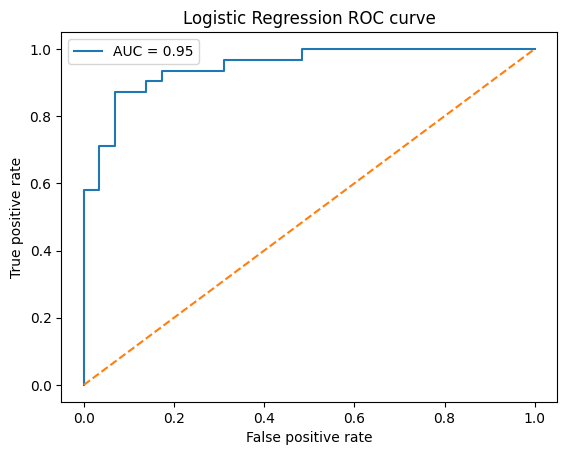

In [59]:
from sklearn.metrics import roc_auc_score,roc_curve

y_prob = lg.predict_proba(x_test)[:,1]   # [:,1] select only probabilities of class 1 .

# auc score
auc = roc_auc_score(y_test,y_prob)
print('AUC score:', auc)

# ROC curve
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr,label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Logistic Regression ROC curve')
plt.legend()
plt.show()

<h4> Logistic Regression performs well on Heart Disease data.

<h5> Accuracy score : 88.3%


Precision : 0.9

Recall : 0.8

AUC : 0.95

<h3>Takeaways

Binary classification.

Medical data understanding and interpretation.

Model evalution using ROC-AUC and confusion matrix.

